# Starter Script for Route Creation

## Imports

In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx
from networkx.algorithms.approximation import traveling_salesman_problem, greedy_tsp
import imageio

## Load Data 

In [ ]:
data = pd.read_csv('../data/data.csv', sep='\t')

## Make Base Graph

In [ ]:
margin = 0.015
max_lat = max(data.loc[:,"latitude"]) + margin
min_lat = min(data.loc[:, "latitude"]) - margin
max_long = max(data.loc[:, "longitude"]) + margin 
min_long = min(data.loc[:, "longitude"]) - margin
# note that I can expand the box by a margin on every side where 0.1 is roughly equivalent to 7 miles.

# Bound box creates a graph from specific latitude and longitude ranges
bbox = (min_long, min_lat, max_long, max_lat) # documentation asks for left, bottom, right, top order

# making graph from the bounds I established 
pickup_graph = ox.graph.graph_from_bbox(bbox, network_type='drive')
pickup_graph = ox.add_edge_speeds(pickup_graph)
pickup_graph = ox.add_edge_travel_times(pickup_graph)

pickup_graph_strong = ox.truncate.largest_component(pickup_graph, strongly=True) # needs a strongly connected graph so nodes hae paths between them

# fig, ax = ox.plot_graph(pickup_graph_strong)


## Nodes

In [ ]:
lat = np.array(data['latitude'])
long = np.array(data['longitude'])

# Creating a node for Valley Recycling
valley_recycling_node = ox.distance.nearest_nodes(pickup_graph_strong, -72.654312, 42.299911)

# Creating list of nodes and adding Valley Recycling to the end of the list
nodes = [ox.distance.nearest_nodes(pickup_graph_strong, long[idx], lat[idx]) for idx in range(len(lat))] # finding nearest node to each PP lat/longitude
nodes = np.array(nodes)
# nodes that may or may node have a duplicate
east_nodes_dupes = nodes[data['city'].values == 'Easthampton']
noho_nodes_dupes = nodes[data['city'].values != 'Easthampton']

# Adding valley recycling to all nodes, Northampton nodes and Easthampton nodes
nodes = np.append(nodes, valley_recycling_node)
east_nodes_dupes = np.append(east_nodes_dupes, valley_recycling_node)
noho_nodes_dupes = np.append(noho_nodes_dupes, valley_recycling_node)

# making variables that only contain the unique nodes
east_nodes = np.unique(east_nodes_dupes)
noho_nodes = np.unique(noho_nodes_dupes)

## Making Aviva's Map of Nodes and Valley Recycling

In [ ]:
fig, ax = ox.plot.plot_graph(pickup_graph_strong, 
                   node_size = 0, 
                   bgcolor = "white", 
                   edge_color = "black",
                   show = False)

for i in range(len(data)): # Plotting the longitudes and latitudes
    plt.plot(long[i], 
            lat[i], 
            marker = "o", 
            color = "green", 
            markersize = 3,
            alpha = 0.65)

# adding valley recycling point
plt.plot(-72.654312, 
        42.299911, 
        marker = "x", 
        color = "red", 
        markersize = 10,
        alpha = 1, 
        mew = 3)

plt.show()

# Making Distance Matrices w Only Unique Nodes

In [ ]:
# Make Noho distance matrix w only unique nodes
noho_distance_matrix = np.zeros((len(noho_nodes), len(noho_nodes)))
for i, u in enumerate(noho_nodes):
    for j, v in enumerate(noho_nodes):
        noho_distance_matrix[i, j] = nx.shortest_path_length(pickup_graph_strong, u, v, weight='length')

# saving as np file        
np.save('../data/noho_distance_matrix_unique', noho_distance_matrix)
# Use np.load() to load the distance matrix

In [ ]:
# Make Easthampton distance matrix w only unique nodes
east_distance_matrix = np.zeros((len(east_nodes), len(east_nodes)))
for i, u in enumerate(east_nodes):
    for j, v in enumerate(east_nodes):
        east_distance_matrix[i, j] = nx.shortest_path_length(pickup_graph_strong, u, v, weight='length')

# saving as np file        
np.save('../data/east_distance_matrix_unique', east_distance_matrix)
# Use np.load() to load the distance matrix

# TSP with Undirected Graph

In [ ]:
## easthampton
# importing the distance matrix from the saved file
east_distance_matrix = np.load('../data/east_distance_matrix_unique.npy')

# making the distance matrix into a complete undirected graph
east_G = nx.from_numpy_array(east_distance_matrix, edge_attr = "distance")

# running TSP
TSP_east = traveling_salesman_problem(east_G, weight="dist ance")
# took 0.2 seconds to run

# saving
np.save('../data/TSP_east', TSP_east)

In [ ]:
## Northampton area
# importing noho distance matrix
noho_distance_matrix = np.load('../data/noho_distance_matrix_unique.npy')

# making the distance matrix into a graph object
noho_G = nx.from_numpy_array(noho_distance_matrix, edge_attr = "distance")

# running TSP
TSP_noho = traveling_salesman_problem(noho_G, weight = "distance")
# took 49 seconds to run

# saving
np.save('../data/TSP_noho', TSP_noho)

# Translating TSP node list into a route

### Easthampton

In [71]:
# loading in TSP route list
TSP_east = np.load('../data/TSP_east.npy')

# making a list of nodes in the pickup order (not just the index)
east_node_order = np.zeros(len(TSP_east))
index = 0
for i in TSP_east:
    east_node_order[index] = east_nodes[i]
    index +=1

In [72]:
# making a list of the length between each pair of nodes, and the route to get there.
east_length = np.zeros(len(east_node_order)-1) 
east_paths = []
for i in range(len(east_node_order)): 
    if i+1 < len(east_node_order): # because i starts at 0 and len() starts at 1
        dist = nx.dijkstra_path_length(pickup_graph_strong, east_node_order[i], east_node_order[i+1], weight = "length") # calculates distance between node and next node
        path = nx.dijkstra_path(pickup_graph_strong, east_node_order[i], east_node_order[i+1], weight = "length") # finds route of nodes to go to get from node to next node
        east_length[i] = dist # stores dist in the larger container of lengths
        east_paths += [path] # stores path in the larger container of paths
    else:
        pass # skip the last node because TSP makes the first and last node the same already, so we know that route/distance (go nowhere, 0 distance)

In [73]:
# calculating the total length of the route
sum(east_length)

np.float64(34186.099768308966)

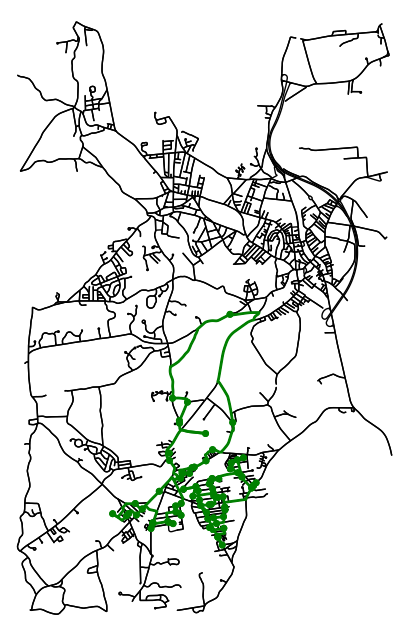

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
# plotting the easthampton route
ox.plot_graph_routes(pickup_graph_strong, east_paths, 
                    # setting up noho map background
                    node_size = .5,
                    bgcolor = "white", 
                    edge_color = "black",
                    node_color = "black", 
                    # setting up route
                    route_linewidths = 2,
                    orig_dest_size = 25,
                    route_alpha = 1, 
                    route_colors = "Green"
                    # save = True,
                    # filepath = "easthampton_route.png"
                    )

### Northampton Area

In [8]:
# loading in TSP route list
TSP_noho = np.load('../data/TSP_noho.npy')

# making a list of nodes in the pickup order (not just the index)
noho_node_order = np.zeros(len(TSP_noho))
index = 0
for i in TSP_noho:
    noho_node_order[index] = noho_nodes[i]
    index +=1

In [9]:
# making a list of the length between each pair of nodes, and the route to get there.
noho_length = np.zeros(len(noho_node_order)-1) 
noho_paths = []
for i in range(len(noho_node_order)): 
    if i+1 < len(noho_node_order): # because i starts at 0 and len() starts at 1
        dist = nx.dijkstra_path_length(pickup_graph_strong, noho_node_order[i], noho_node_order[i+1], weight = "length") # calculates distance between node and next node
        path = nx.dijkstra_path(pickup_graph_strong, noho_node_order[i], noho_node_order[i+1], weight = "length") # finds route of nodes to go to get from node to next node
        noho_length[i] = dist # stores dist in the larger container of lengths
        noho_paths += [path] # stores path in the larger container of paths
    else:
        pass # skip the last node because TSP makes the first and last node the same already, so we know that route/distance (go nowhere, 0 distance)

In [10]:
# calculating the total length of the route
sum(noho_length)

np.float64(101993.50260640982)

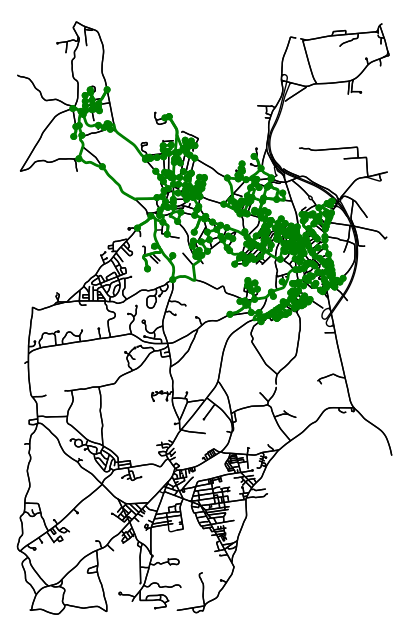

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
# plotting the noho route
ox.plot_graph_routes(pickup_graph_strong, noho_paths, 
                    # setting up noho map background
                    node_size = .5,
                    bgcolor = "white", 
                    edge_color = "black",
                    node_color = "black", 
                    # setting up route
                    route_linewidths = 2,
                    orig_dest_size = 25,
                    route_alpha = 1, 
                    route_colors = "Green"
                    # save = True,
                    # filepath = "nohohampton_route.png"
                    )

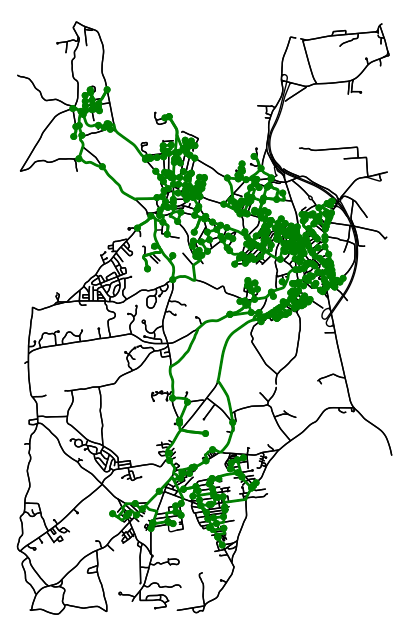

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [20]:
all_paths = noho_paths + east_paths
# plotting the route
ox.plot_graph_routes(pickup_graph_strong, all_paths, 
                    # setting up noho map background
                    node_size = .5,
                    bgcolor = "white", 
                    edge_color = "black",
                    node_color = "black", 
                    # setting up route
                    route_linewidths = 2,
                    orig_dest_size = 25,
                    route_alpha = 1, 
                    route_colors = "Green"
                    # save = True,
                    # filepath = "all_route.png"
                    )

# Checking our assumption that the effect of one-way streets is negligible

In [66]:
# loading distance matrix
east_distance_matrix = np.load('../data/east_distance_matrix_unique.npy')

# calculating the difference between going A -> B vs B-> A, as well as the proportion that is of the overall path distance
east_dist_diff = []
east_prop = []
for i in range(len(east_distance_matrix)):
    for u in range(len(east_distance_matrix)):
        if i == u:
            pass
        else:
            dist_diff = abs(east_distance_matrix[i, u] - east_distance_matrix[u, i])
            prop = dist_diff / east_distance_matrix[i, u]
            east_dist_diff += [dist_diff]
            east_prop += [prop]


print(sum(east_dist_diff)/len(east_dist_diff))
print(sum(east_prop)/len(east_prop))

24.953851835625922
0.010634344167537004


In [65]:
# loading distance matrix
noho_distance_matrix = np.load('../data/noho_distance_matrix_unique.npy')

# calculating the difference between going A -> B vs B-> A, as well as the proportion that is of the overall path distance
noho_dist_diff = []
noho_prop = []
for i in range(len(noho_distance_matrix)):
    for u in range(len(noho_distance_matrix)):
        if i == u:
            pass
        else:
            dist_diff = abs(noho_distance_matrix[i, u] - noho_distance_matrix[u, i])
            prop = dist_diff / noho_distance_matrix[i, u]
            noho_dist_diff += [dist_diff]
            noho_prop += [prop]


print(sum(noho_dist_diff)/len(noho_dist_diff))
print(sum(noho_prop)/len(noho_prop))

26.139850898449343
0.008459757833872697


# STORAGE - CODE IS NOT FUNCTIONAL/PRACTICAL RN

## Code for Making Distance Matrices w All Nodes

In [ ]:
# Make Noho distance matrix, takes 11 minutes to run
noho_distance_matrix = np.zeros((len(noho_nodes), len(noho_nodes)))
for i, u in enumerate(noho_nodes):
    for j, v in enumerate(noho_nodes):
        noho_distance_matrix[i, j] = nx.shortest_path_length(pickup_graph_strong, u, v, weight='length')

np.save('../data/noho_distance_matrix', noho_distance_matrix)
# Use np.load() to load the distance matrix

In [ ]:
east_distance_matrix = np.zeros((len(east_nodes), len(east_nodes)))
for i, u in enumerate(east_nodes):
    for j, v in enumerate(east_nodes):
        east_distance_matrix[i, j] = nx.shortest_path_length(pickup_graph, u, v, weight='length')

In [ ]:
np.save('../data/east_distance_matrix', east_distance_matrix)

# Code for TSP with directed graph

In [ ]:
# making the distance matrix into a complete directed graph
east_G_directed = nx.from_numpy_array(east_distance_matrix, edge_attr = "distance", create_using =nx.DiGraph) 

# running TSP
TSP_east_directed = traveling_salesman_problem(east_G_directed, weight="distance")

In [ ]:
# making the distance matrix into a directed graph object
noho_G_directed = nx.from_numpy_array(noho_distance_matrix, edge_attr = "distance", create_using =nx.DiGraph)

# running TSP
TSP_noho_directed = traveling_salesman_problem(noho_G_directed, weight = "distance")